In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("AcademicPerformance.csv")
df.info()
print("-----------------------------------")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rollno  100 non-null    int64  
 1   Marks   100 non-null    float64
 2   Gender  100 non-null    int64  
 3   Age     84 non-null     float64
 4   PhD     87 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 4.0+ KB
-----------------------------------


,Rollno,Marks,Gender,Age,PhD
0,1,140.0,1,47.0,Yes
1,2,30.0,0,65.0,Yes
2,3,35.1,0,56.0,No
3,4,30.0,1,23.0,No
4,5,80.0,0,NaN,Yes


In [6]:
df.isnull().sum()


Rollno     0
Marks      0
Gender     0
Age       16
PhD       13
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.loc[df['Marks'] < 0, 'Marks'] = df['Marks'].mean()
df.isnull().sum() 

Rollno     0
Marks      0
Gender     0
Age        0
PhD       13
dtype: int64

Skewness of Marks column: 1.08


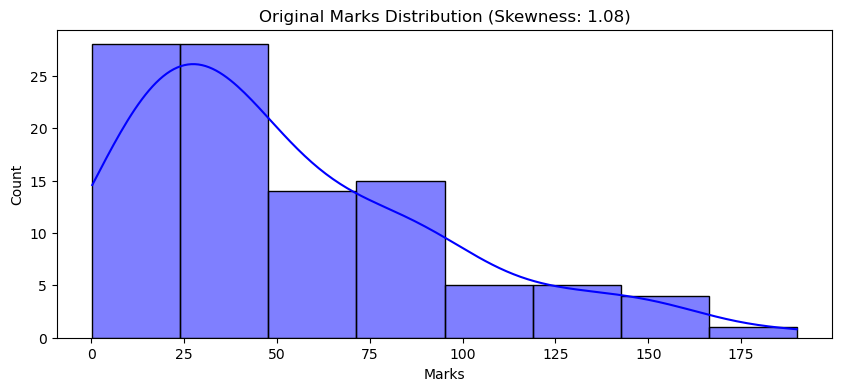

In [10]:
marks_skew = df['Marks'].skew()
print(f"Skewness of Marks column: {marks_skew:.2f}")


plt.figure(figsize=(10, 4))
sns.histplot(df['Marks'], kde=True, color='blue')
plt.title(f"Original Marks Distribution (Skewness: {marks_skew:.2f})")
plt.show()

In [14]:
df['Marks_Transformed'] = np.log1p(df['Marks'])
transformed_skew = df['Marks_Transformed'].skew()
print(f"Skewness after Log Transformation: {transformed_skew:.2f}")

Skewness after Log Transformation: -0.93


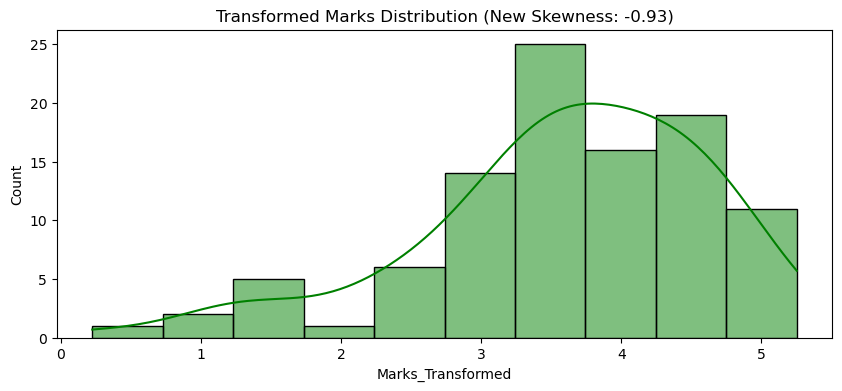

--- Comparison of Original vs Transformed ---


,Marks,Marks_Transformed
0,140.0,4.948760
1,30.0,3.433987
2,35.1,3.586293
3,30.0,3.433987
4,80.0,4.394449


In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Marks_Transformed'], kde=True, color='green')
plt.title(f"Transformed Marks Distribution (New Skewness: {transformed_skew:.2f})")
plt.show()

print("--- Comparison of Original vs Transformed ---")
df[['Marks', 'Marks_Transformed']].head()